# Libraries

In [1]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from astropy.table import Column
from scipy.stats import bootstrap

from __future__ import annotations
import os
import json
from astropy.cosmology import FlatwCDM

import pymultinest
import corner
from getdist import plots, MCSamples
import scipy.optimize as op
from scipy import stats

# Visualizacion

In [10]:
Galaxy = 'M81'
Method = 'CEPHEIDS'

with fits.open('modulus_tracker.fits') as hdulist:
    
    # Iterar sobre cada HDU en la lista
    for hdu in hdulist:
        header = hdu.header
        
        # Aplicar los criterios de búsqueda
        # Verificar si 'EXTNAME' existe Y si 'TELESCOP' existe y coincide
        if ('EXTNAME' in header and header['EXTNAME'] == Galaxy) and \
           ('METHOD' in header and header['METHOD'] == Method):
            
            # Si ambos criterios coinciden, hemos encontrado nuestro HDU
            hdu_encontrado = hdu
            print(f"\nHDU número {hdulist.index(hdu)}.\n")
            Tabla = Table.read(hdu)
            #print(Tabla)
            # Puedes salir del bucle si solo esperas uno
            break 
    
    # 3. Usar el HDU encontrado
    if hdu_encontrado is not None:
        print("\nCabecera del HDU:\n")
        print(repr(hdu_encontrado.header)) # Imprime una representación completa de la cabecera
        # Aquí puedes acceder a los datos: hdu_encontrado.data
    else:
        print("\nNo se encontró ningún HDU que coincida con ambos criterios.")

Tabla


HDU número 7.


Cabecera del HDU:

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1067 / length of dimension 1                          
NAXIS2  =                   15 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   16 / number of table fields                         
METHOD  = 'CEPHEIDS'           / Cepheids PLR method                            
EXTNAME = 'M81     '           / Name of Host Galaxy                            
TTYPE1  = 'RefCode '           / Article's RefCode                              
TFORM1  = '40A     '                                                     

RefCode,Citation,Band,mu_0,e_R,e_S,e_T,Category,Ncef,Zcorr,zeroP,Rank,Year,Date,Comments,Author
str40,str40,str40,float64,float64,float64,float64,int64,int64,bool,str20,int64,int64,str12,str800,str50
2000ApJ...529..745F,Ferrarese et al.2000,W(VI),27.8,0.08,--,--,1,30,False,LMC,1,2000,2024,1,Valencia et al.2024
2001ApJ...548..564W,Willick & Batra 2001,W(VI),27.66,0.09,--,--,1,25,False,LMC,1,2001,2024,2,Valencia et al.2024
2001ApJ...549..721M,Macri et al.2001,H,27.91,0.08,--,--,1,6,False,LMC,1,2001,2024,3,Valencia et al.2024
2001ApJ...553...47F,Freedman et al.2001,W(VI),27.75,0.08,--,--,1,17,False,LMC,1,2001,2024,na,Valencia et al.2024
2001ApJ...553...47F,Freedman et al.2001,W(VI),27.8,0.08,--,--,1,17,True,LMC,1,2001,2024,4,Valencia et al.2024
2002A&A...389...19P,"Paturel, G. et al.2002",W(VI),27.66,0.08,--,--,1,92,False,GC,1,2002,2024,5,Valencia et al.2024
2003A&A...411..361K,"Kanbur, S. M. et al.2003",W(VI),27.79,0.09,--,--,1,17,False,LMC,1,2003,2024,6,Valencia et al.2024
2003A&A...411..361K,"Kanbur, S. M. et al.2003",W(VI),27.85,0.1,--,--,1,17,False,GC,1,2003,2024,7,Valencia et al.2024
2004ApJ...608...42S,Sakai et al.2004,BVRI,27.75,0.08,--,--,1,-1,False,LMC,1,2004,2024,8,Valencia et al.2024


In [32]:
S = fits.open('modulus_tracker.fits')

gal_host = 33

P = Table.read(S[gal_host])

print(S[gal_host].header['EXTNAME'],' - ',S[gal_host].header['METHOD'])

P = P[(P['Zcorr']==False)  &  (P['e_T']>= 0)]

G1_m = np.array(P['mu_0'])
G1_e = np.array(P['e_T'])
Galaxia = S[gal_host].header['EXTNAME']
N_dat = len(P)
mu_w = round(weighted_average(G1_m,G1_e),3)
sigma_w = round(weighted_error(G1_e),3)

print(N_dat)

NGC6822  -  CEPHEIDS
13


In [6]:
S.info()

Filename: modulus_tracker.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (1, 1)   float64   
  1  IC0010        1 BinTableHDU     58   1R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  2  IC0010        1 BinTableHDU     34   13R x 10C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A]   
  3  IC2574        1 BinTableHDU     58   0R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  4  IC2574        1 BinTableHDU     34   5R x 10C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A]   
  5  M33           1 BinTableHDU     58   14R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  6  M33           1 BinTableHDU     34   15R x 10C   [40A, 40A, 40A, D, D, K, K, 12A, 800A, 50A]   
  7  M81           1 BinTableHDU     58   15R x 16C   [40A, 40A, 40A, D, D, D, D, K, K, L, 20A, K, K, 12A, 800A, 50A]   
  8  M81           1 BinTableHDU     34   9R x 10C   [40A, 40

# Functions

In [4]:
def weighted_average(modulus,error):
    modulus,error = np.array(modulus),np.array(error)
    err_sq_inv = 1 / ((error)**2)
    num = np.sum(err_sq_inv * modulus)
    dem = np.sum(err_sq_inv)

    return num/dem

def weighted_error(error):
    error = np.array(error)
    err_sq_inv = 1 / ((error)**2)
    dem = np.sum(err_sq_inv)

    return 1 / np.sqrt(dem)

def bootstrap_error(modulus,error,N=200000,CL = 0.95,Method = 'basic'):
    res = bootstrap(
        (modulus,error),                     # El argumento data debe ser una tupla de arrays
        weighted_average,          # La función que calcula el estadístico
        n_resamples=N,             # Número de remuestras
        confidence_level=CL,        # Nivel de confianza del 95%
        method=Method,          # Método más simple para el interval
    )

    br_dist = res.bootstrap_distribution

    N_dist = len(res.bootstrap_distribution)

    br_mean = np.mean(br_dist)

    quad_br = (br_dist-br_mean)**2

    plt.hist(br_dist)

    return np.sqrt(((1)/(N_dist-1)) * np.sum(quad_br))


def bootstrap_error2(modulus,error,N=200000):
    modulus,error = np.array(modulus),np.array(error)
    size = len(modulus)

    n_bootstraps = N  # Number of bootstrap iterations
    bootstrap_statistics = []

    for i in range(n_bootstraps):
        # Create a resample with replacement, same size as original data
        bootstrap_sample = np.random.choice(size, size=size, replace=True)

        modulus_sample = modulus[bootstrap_sample]
        error_sample = error[bootstrap_sample]

        sample_mean = weighted_average(modulus_sample,error_sample)
        bootstrap_statistics.append(sample_mean)

    bootstrap_statistics = np.array(bootstrap_statistics)

    N_dist = len(bootstrap_statistics)

    br_mean = np.mean(bootstrap_statistics)

    quad_br = (bootstrap_statistics-br_mean)**2
    
    lower_bound = np.percentile(bootstrap_statistics, 15.87)
    upper_bound = np.percentile(bootstrap_statistics, 84.13)

    return [np.sqrt(((1)/(N_dist-1)) * np.sum(quad_br)),
           [br_mean - lower_bound, upper_bound - br_mean],
            bootstrap_statistics]

    
def cochran_error(modulus,error):
    Mu_i,Er_i = np.array(modulus),np.array(error)
    n = len(Mu_i)
    w_i = 1 / ((Er_i)**2)

    Mu_w = weighted_average(Mu_i,Er_i)
    w_mean = np.mean(w_i)

    s1 = n / ((n-1) * (np.sum(w_i))**2)
    s2 = (w_i * Mu_i  - (w_mean * Mu_w))**2
    s3 = (w_i - w_mean) * ((w_i*Mu_i) - (w_mean*Mu_w)) 
    s4 = (w_i - w_mean)**2

    return np.sqrt(s1 * (np.sum(s2) - (2 * Mu_w * np.sum(s3)) +    (Mu_w**2 * np.sum(s4)) ) )

def confidencelevel_error(modulus,error,N=200000,CL = 0.68,Method = 'basic'):
    res = bootstrap(
        (modulus,error),                     # El argumento data debe ser una tupla de arrays
        weighted_average,          # La función que calcula el estadístico
        n_resamples=N,             # Número de remuestras
        confidence_level=CL,        # Nivel de confianza del 95%
        method=Method,          # Método más simple para el interval
    )

    upper = res.confidence_interval.high
    lower = res.confidence_interval.low

    Mu_w = weighted_average(modulus,error)

    plt.hist(res.bootstrap_distribution)

    return [Mu_w-lower,upper-Mu_w]


def nestedsampling_error(modulus,error,steps=10000, Name='', group = ''):

    def prior_transform(x):
        mu = 20 * x + 20
        return mu
    
    def lnlike(theta, m, merr):
        mu_pi = theta
        R = (mu_pi - m)
        W = 1.0/(merr**2)
        xsq = np.sum(R**2 * W)
        L = -0.5*xsq
        return L
    
    def loglike_for_mnest(theta):
        return lnlike(theta, modulus, error)
    
    outdir = os.path.join('NS', group)
    os.makedirs(outdir, exist_ok=True)
    prefix = os.path.join(outdir, Name)

    n_dims = 1
    result = pymultinest.solve(
        LogLikelihood=loglike_for_mnest,
        Prior=prior_transform,
        n_dims=n_dims,
        outputfiles_basename=prefix,
        evidence_tolerance=0.5,
        n_live_points=steps,
        multimodal=True,
        verbose=False,
    )

    samples = result["samples"] 
    T_sample = samples.T


    # calcula loglike para cada muestra
    logL = np.array([loglike_for_mnest(s) for s in samples])

    # punto MAP (aprox): el de mayor logL
    #theta_map = samples[np.argmax(logL)]

    # chi^2 en MAP
    chi2_map = -2.0*np.max(logL)

    N = len(modulus)   # número de datos
    k = n_dims         # parámetros del modelo
    nu = N - k
    chi2_red = chi2_map / nu

    sigma2_corr = T_sample.std() * chi2_red

    return [T_sample.std(),sigma2_corr]

def maxlikelicorr_error(modulus,error,Name='',group = ''):

    sigma_L_sq = (nestedsampling_error(modulus,error,Name=Name,group=group))**2

    outdir = os.path.join('NS', group) 
    prefix = os.path.join(outdir, Name)

    analyzer = pymultinest.analyse.Analyzer(n_params = 1, outputfiles_basename=prefix)

    ln_L_max = analyzer.get_stats()['modes'][0]['maximum a posterior'][0] * analyzer.get_stats()['global evidence'] * -1

    chi2_min = -2.0 * ln_L_max

    nu = len(modulus) - 1 

    chi2_corr = (chi2_min / nu) * -1

    sigma_corr = sigma_L_sq * chi2_corr

    return np.sqrt(sigma_corr)

    


# Tests

In [ ]:
if os.path.exists('t_r.csv'):
    DF = pd.read_csv('t_r.csv')
else:
    S = fits.open('modulus_tracker.fits')
    t_r = []
    t_r =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'TRGB') and (len(T)>0):
            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_R'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)
            mu_w = round(weighted_average(G1_m,G1_e),3)
            sigma_w = round(weighted_error(G1_e),3)

            if N_dat <= 1:
                t_r.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            else:
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000)
                sigma_br = round(sigma_br,3)
                sigma_cl[0] = round(sigma_cl[0],3)
                sigma_cl[1] = round(sigma_cl[1],3)
                sigma_C = round(cochran_error(G1_m,G1_e),3)
                sigma_L = round(nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'trgb')[0],3)
                sigma_Lcorr = round(nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'trgb')[1],3)
                t_r.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = t_r[10:],columns = t_r[0:10])
    DF.to_csv('t_r.csv')

DF


,Unnamed: 0,Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl+,sigma_cl-,sigma_L,sigma_Lcorr
0,0,IC0010,13,24.309,0.012,0.025,0.026,0.025,0.025,0.012,0.044
1,1,IC2574,5,27.919,0.015,0.014,0.016,0.015,0.015,0.015,0.015
2,2,M33,15,24.706,0.015,0.031,0.03,0.03,0.03,0.015,0.046
3,3,M81,9,27.783,0.013,0.025,0.022,0.022,0.023,0.013,0.046
4,4,M101,26,29.268,0.006,0.015,0.015,0.015,0.015,0.006,0.024
5,5,MRK116,1,31.300,0.170,--,--,--,--,--,--
6,6,NGC2366,5,27.559,0.021,0.021,0.013,0.015,0.012,0.02,0.01
7,7,NGC2403,5,27.488,0.026,0.023,0.025,0.024,0.026,0.026,0.016
8,8,NGC4214,11,27.359,0.017,0.021,0.021,0.023,0.022,0.017,0.013
9,9,NGC4236,3,28.233,0.089,0.049,0.017,0.026,0.012,0.09,0.012


In [ ]:
if os.path.exists('cm_t.csv'):
    DF = pd.read_csv('cm_t.csv')
else:
    S = fits.open('modulus_tracker.fits')
    cm_t = []
    cm_t =['Galaxia','N_dat','mu_w','sigma_w','sigma_br','sigma_C','sigma_cl+','sigma_cl-','sigma_L','sigma_Lcorr']

    for i in range(1,64):

        gal_host = i

        T = Table.read(S[gal_host])

        if (S[gal_host].header['METHOD'] == 'CEPHEIDS') and (len(T)>0):

            T = T[(T['Zcorr']==True)  &  (T['e_T']>= 0)]

            G1_m = np.array(T['mu_0'])
            G1_e = np.array(T['e_T'])
            Galaxia = S[gal_host].header['EXTNAME']
            N_dat = len(T)
            mu_w = round(weighted_average(G1_m,G1_e),3)
            sigma_w = round(weighted_error(G1_e),3)

            if N_dat <= 1:
                cm_t.append([Galaxia,N_dat,mu_w,sigma_w,'--','--','--','--','--','--'])        
            else:
                sigma_br,sigma_cl,Br_stats = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000)
                sigma_br = round(sigma_br,3)
                sigma_cl[0] = round(sigma_cl[0],3)
                sigma_cl[1] = round(sigma_cl[1],3)
                sigma_C = round(cochran_error(G1_m,G1_e),3)
                sigma_L = round(nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'cm_t')[0],3)
                sigma_Lcorr = round(nestedsampling_error(G1_m,G1_e,Name=Galaxia,group = 'cm_t')[1],3)
                cm_t.append([Galaxia,N_dat,mu_w,sigma_w,sigma_br,sigma_C,sigma_cl[0],sigma_cl[1],sigma_L,sigma_Lcorr])

    S.close()

    DF = pd.DataFrame(data = cm_t[10:],columns = cm_t[0:10])
    DF.to_csv('cm_t.csv')

DF


/tmp/ipykernel_521394/3786299296.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return num/dem
/tmp/ipykernel_521394/3786299296.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 / np.sqrt(dem)


 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = ****
 dimensionality =    1
 *****************************************************


Exception ignored on calling ctypes callback function <function run.<locals>.loglike at 0x14f65d592c00>:
Traceback (most recent call last):
  File "/home/holman/.conda/envs/nest/lib/python3.13/site-packages/pymultinest/run.py", line 220, in loglike
    def loglike(cube, ndim, nparams, lnew, nullcontext):
KeyboardInterrupt: 


# Plots

<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_522316/1821641958.py:70: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\mu \pm 1\sigma$ ({std_mu_pi:.2f})')


  analysing data from NS/trgb/M101.txt


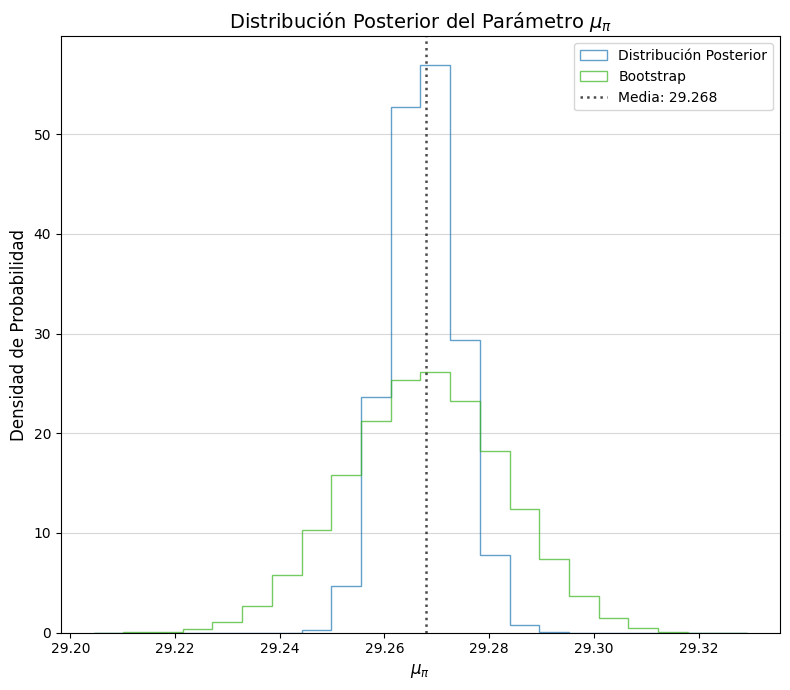

In [ ]:
S = fits.open('modulus_tracker.fits')

Galaxia = 'M101'
metodo = 'TRGB'

for hdu in S:
    header = hdu.header
    
    # Aplicar los criterios de búsqueda
    # Verificar si 'EXTNAME' existe Y si 'TELESCOP' existe y coincide
    if ('EXTNAME' in header and header['EXTNAME'] == Galaxia) and \
        ('METHOD' in header and header['METHOD'] == metodo):
        # Si ambos criterios coinciden, hemos encontrado nuestro HDU
        hdu_encontrado = hdu
        P = Table.read(hdu)
        #print(Tabla)
        # Puedes salir del bucle si solo esperas uno
        break 

G1_m = np.array(P['mu_0'])
G1_e = np.array(P['e_R'])

n_dims = 1  # Tu único parámetro (mu_pi)
outdir = os.path.join('NS', "trgb") 
prefix = os.path.join(outdir, "M101")

samples  = pymultinest.analyse.Analyzer(n_params = 1, outputfiles_basename=prefix)

mu_pi_samples = samples.get_equal_weighted_posterior()[:,0]

bootstrap_pahist = bootstrap_error2(modulus = G1_m,error = G1_e,N=200000)[2]

binS = np.histogram_bin_edges(bootstrap_pahist, bins='doane')

plt.figure(figsize=(8, 7))

# Plotear el histograma
# `density=True` normaliza el histograma para que el área bajo las barras sea 1, 
# haciendo que parezca una función de densidad de probabilidad.
plt.hist(mu_pi_samples, bins=binS, density=True, 
         color='#1f77b4', alpha=0.7, label='Distribución Posterior',histtype='step')

plt.hist(bootstrap_pahist, bins=binS, density=True, 
         color="#3ab41f", alpha=0.7, label='Bootstrap',histtype='step')

# --- 5. Añadir Información Clave (Media y Desviación Estándar) ---
mean_mu_pi = round(weighted_average(G1_m,G1_e),3)
std_mu_pi = np.std(mu_pi_samples)

# Trazar la media (Estimación del parámetro)
plt.axvline(mean_mu_pi, color='black', linestyle='dotted', linewidth=1.8, alpha = 0.7, 
            label=f'Media: {mean_mu_pi:.3f}')

'''
std_mu_pi = 0.025
# Define los límites de 1-sigma
lower_limit = mean_mu_pi - std_mu_pi
upper_limit = mean_mu_pi + std_mu_pi

line_height = plt.ylim()[1] * 0.5  # 80% de la altura máxima del plot

# B. Dibujar la línea horizontal (la barra de 1-sigma)
plt.hlines(y=line_height, 
           xmin=lower_limit, 
           xmax=upper_limit, 
           color='red', alpha = 0.3,
           linewidth=1.5, 
           label=f'$\mu \pm 1\sigma$ ({std_mu_pi:.2f})')

# C. Dibujar las barras verticales de los límites (las cotas)
# Cota Inferior (-1 sigma)
plt.vlines(x=lower_limit, 
           ymin=line_height - (plt.ylim()[1]*0.02), # Pequeño offset para la barra vertical
           ymax=line_height + (plt.ylim()[1]*0.02), 
           color='red', alpha = 0.3,linestyles='-',
           linewidth=1.5)

# Cota Superior (+1 sigma)
plt.vlines(x=upper_limit, 
           ymin=line_height - (plt.ylim()[1]*0.02), 
           ymax=line_height + (plt.ylim()[1]*0.02), 
           color='red', alpha = 0.3,
           linewidth=1.5)


bootstrap_min = min(bootstrap_pahist)
bootstrap_max = max(bootstrap_pahist)
plt.xlim(mean_mu_pi-0.1,mean_mu_pi+0.1)
'''

# --- 6. Formato del Plot ---
plt.title(r'Distribución Posterior del Parámetro $\mu_\pi$', fontsize=14)
plt.xlabel(r'$\mu_\pi$', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

S.close()

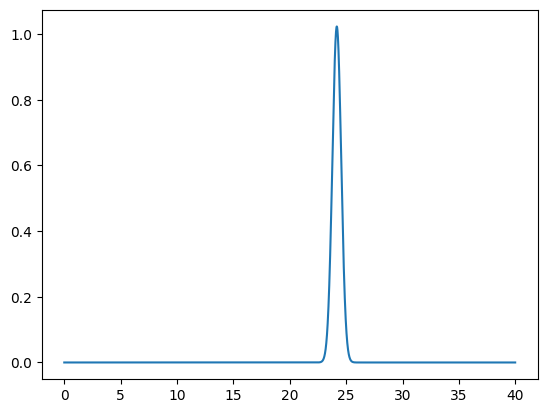

In [ ]:
def bell_curve(mu,sigma):

    x = np.arange(0,40,0.01)

    s1 = 1 / (sigma * np.sqrt(2*np.pi))

    s2  = np.exp(-0.5 * ((x - mu)/(sigma))**2)

    return [x,(s1*s2)]

plt.plot(bell_curve(24.17,0.39)[0],bell_curve(24.17,0.39)[1])
